In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.python.training.experimental.mixed_precision import disable_mixed_precision_graph_rewrite_v1

In [3]:
df2 = pd.read_csv('ICSA.csv')
df2['observation_date'] = pd.to_datetime(df2['observation_date'])
df2_monthly = df2.set_index('observation_date').resample('ME').mean()
print(df2_monthly.head())
df2_monthly.to_csv("ICSA-monthly.csv")

                      ICSA
observation_date          
1967-01-31        209000.0
1967-02-28        229000.0
1967-03-31        260750.0
1967-04-30        263000.0
1967-05-31        235750.0


In [4]:
df2 = pd.read_csv('CCSA.csv')
df2['observation_date'] = pd.to_datetime(df2['observation_date'])
df2_monthly = df2.set_index('observation_date').resample('ME').mean()
df2_monthly.head()
df2_monthly.to_csv("CCSA-monthly.csv")

In [5]:
def read_all_then_join(datalist):
    data = pd.read_csv(datalist[0])

    for index, _ in enumerate(datalist):
        if index > 0:
            df = pd.read_csv(datalist[index])
            df["observation_date"] = pd.to_datetime(df["observation_date"])
            df["observation_date"] = df["observation_date"].dt.to_period("M")
            data = pd.merge(data, df, on = "observation_date", how = "inner")
        else:
            data["observation_date"] = pd.to_datetime(data["observation_date"])
            data["observation_date"] = data["observation_date"].dt.to_period("M")
            print(data.head())
    return data


data = read_all_then_join(["ICSA-monthly.csv", "JTSJOL.csv","PAYEMS.csv","UMCSENT.csv","UNRATE.csv", "JTSLDL.csv", "CCSA-monthly.csv"])
data.tail()

  observation_date      ICSA
0          1967-01  209000.0
1          1967-02  229000.0
2          1967-03  260750.0
3          1967-04  263000.0
4          1967-05  235750.0


,observation_date,ICSA,JTSJOL,PAYEMS,UMCSENT,UNRATE,JTSLDL,CCSA
290,2025-02,226000.0,7480,159155,64.7,4.1,1780,1859750.0
291,2025-03,223200.0,7200,159275,57.0,4.2,1590,1863200.0
292,2025-04,226000.0,7395,159433,52.2,4.2,1789,1872750.0
293,2025-05,234000.0,7712,159452,52.2,4.2,1611,1906000.0
294,2025-06,241250.0,7437,159466,60.7,4.1,1604,1952750.0


In [6]:
data.index = data['observation_date']
data.drop('observation_date', axis = 1, inplace = True)
data.head()

,ICSA,JTSJOL,PAYEMS,UMCSENT,UNRATE,JTSLDL,CCSA
observation_date,,,,,,,
2000-12,346000.0,5088,132716,98.4,3.9,2018,2306400.0
2001-01,340000.0,5234,132703,94.7,4.2,2220,2395750.0
2001-02,371250.0,5097,132788,90.6,4.2,1855,2486500.0
2001-03,387200.0,4762,132751,91.5,4.3,2133,2585400.0
2001-04,396750.0,4615,132457,88.4,4.4,1883,2697250.0


In [17]:
#incorrect assignment of X features and y labels. X features must be a list of lags that correspond with the appropriate label. e.g. X = [2000-1 -> 2000-6] y =  unrate for 2000-7. you must append y to X and increment the starting index of X by 1 to create the next training and label pair. e.g. X = 2000-2 -> 2000-7 Y = unrate for 2000-8.
#Input (X) = [rows 1–24 of unemployment, CPI, GDP, interest_rate]
#Label (y) = [row 25 unemployment]

X_data = data.loc["2000-12":"2020-1"].drop(["UNRATE"], axis=1)
y_data = data["UNRATE"]
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler(feature_range = (0,1))
#scaler = StandardScaler()
n_lags = 5
X, y = [], []
for i in range(n_lags, len(X_data)):
    X.append(X_data[i - n_lags : i])   # the 10 lagged values
    y.append(y_data.iloc[i])
X = np.array(X)
y = np.array(y)
n = len(X)
train_end = int(n * 0.8)
X_train = X[:train_end]
dim1,dim2,dim3 = X_train.shape
X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_train = scaler.fit_transform(X_train)
X_train = X_train.reshape(dim1, dim2, dim3)
y_train = y[:train_end]
y_train = y[:train_end]
X_test = X[train_end:]
y_test = y[train_end:]

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
model = Sequential([
    LSTM(256, activation="tanh", input_shape=(n_lags, X.shape[2])),
    Dense(1)  # predict CES
])

model.compile(optimizer="adam", loss="mse", metrics = ["mae"])
model.summary()
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)



2026-03-15 18:04:54.669166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-15 18:04:55.196256: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-15 18:04:55.258060: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 18:04:55.955200: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 18:05:01.690020: W tensorflow/compiler/tf2

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │       269,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,569 (1.03 MB)

 Trainable params: 269,569 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


2026-03-15 18:05:10.356837: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 40.3442 - mae: 6.0718 - val_loss: 21.1584 - val_mae: 4.4871
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 15.8480 - mae: 3.3495 - val_loss: 9.2158 - val_mae: 2.5388
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.0267 - mae: 2.3349 - val_loss: 1.7149 - val_mae: 1.1511
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2190 - mae: 1.4940 - val_loss: 1.5414 - val_mae: 1.0436
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.7966 - mae: 1.4718 - val_loss: 1.0429 - val_mae: 0.8760
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.0215 - mae: 1.2786 - val_loss: 1.3506 - val_mae: 0.9075
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.6774 - mae: 1.0295 - val_loss: 1.2208 - val_mae: 0.9443
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.2338 - mae: 0.9225 - val_loss: 1.7045 - val_mae: 1.2416
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0585 - mae: 0.8151 - val_loss

In [49]:
X_test

array([[[2.75200e+05, 5.46700e+03, 1.42125e+05, 9.19000e+01,
         1.77300e+03, 2.25400e+06],
        [2.69500e+05, 5.48800e+03, 1.42275e+05, 8.72000e+01,
         1.96400e+03, 2.24300e+06],
        [2.67000e+05, 5.77300e+03, 1.42579e+05, 9.00000e+01,
         1.84500e+03, 2.20760e+06],
        ...,
        [2.63250e+05, 6.12900e+03, 1.43662e+05, 9.10000e+01,
         1.85000e+03, 2.16725e+06],
        [2.66000e+05, 5.80300e+03, 1.43855e+05, 8.90000e+01,
         1.77100e+03, 2.14900e+06],
        [2.74500e+05, 5.77700e+03, 1.43900e+05, 9.47000e+01,
         1.82500e+03, 2.16975e+06]],

       [[2.69500e+05, 5.48800e+03, 1.42275e+05, 8.72000e+01,
         1.96400e+03, 2.24300e+06],
        [2.67000e+05, 5.77300e+03, 1.42579e+05, 9.00000e+01,
         1.84500e+03, 2.20760e+06],
        [2.68500e+05, 5.70800e+03, 1.42808e+05, 9.13000e+01,
         1.77900e+03, 2.20850e+06],
        ...,
        [2.66000e+05, 5.80300e+03, 1.43855e+05, 8.90000e+01,
         1.77100e+03, 2.14900e+06],
  

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


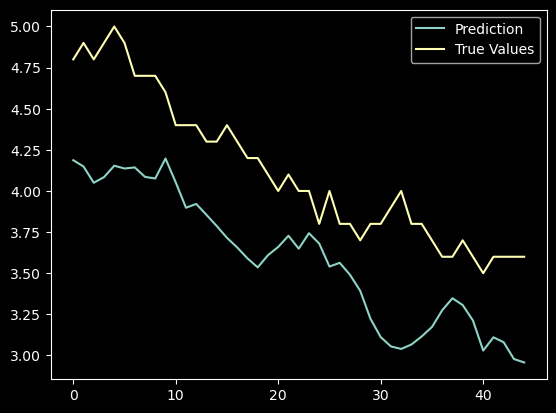

In [18]:
dim1,dim2,dim3 = X_test.shape
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])
X_test = scaler.transform(X_test)
X_test = X_test.reshape(dim1, dim2, dim3)
#X_test = scaler.inverse_transform(X_test)
y_pred = model.predict(X_test)
plt.plot(y_pred, label = "Prediction")
plt.plot(y_test, label = "True Values")
plt.legend()
plt.show()